## Performance Metrics

#### Qa Implement the Accuracy function and test it on the MNIST data.

We now follow the convention in Scikit-learn, that a score funtion takes the arguments `y_true` and then `y_pred`

```
    sklearn.metrics.accuracy_score(y_true, y_pred, ..)
```

Implement a general accuracy function `MyAccuracy(y_true, y_pred)`. Again, implement the function you self from scratch, i.e. do not use any helper functions from Scikit-learn (implementing via `sklearn.metrics.confusion_matrix` is also not allowed, othewise you will then learn nothing!)

Reuse your MNIST data loader and test the `MyAccuracy` function  both on your dummy classifier and on the Stochastic Gradient Descent classifier (with setup parameters as in [HOML]).

Remember to use the '5/not-5' ground-truth data, ala

```python
    y_train_5 = (y_train == '5')    
    y_test_5  = (y_test == '5')
```

not the full 10 class MNIST output categories, since we are dealing with metrics handling only pure binary classifiers (well, there is a way to deal with this using micro/macro averaging of multiclass classifiers, you meet these in the gridsearch exercise later).

Compare your accuracy score with the acutal value from `sklearn.metrics.accuracy_score()`.

(Implementation note: what do you do, if the denominator is zero?)

The actual value of X[0]: 5


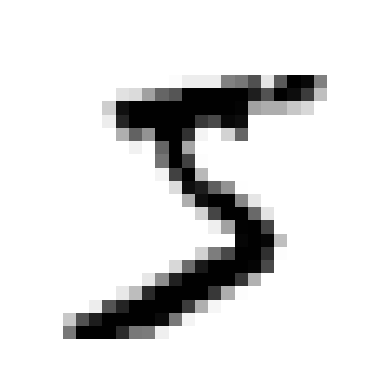

In [ ]:
# MNIST Data loader
# TODO: Fix daniels løsning her

%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml

def MNIST_GetDataSet():
    return fetch_openml('mnist_784',return_X_y=True, as_frame=False) # Returns (data, target)
    
y_true, y_pred = MNIST_GetDataSet()
print(f'The actual value of X[0]: {y[0]}')

def MNIST_PlotDigit(data):
    image = data.reshape(28,28)
    plt.imshow(image, cmap = matplotlib.cm.binary, interpolation="nearest")
    plt.axis("off")

MNIST_PlotDigit(X[0])
plt.show()

An accuracy function implemented in pure python to calculate the accuracy of an algorithm. This function calculates the True Positives, True Negatives, False Positives and False Negatives.
The accuracy is calculated by dividing the sum of True Positive and True Negative with the total.

$\frac{(\sum TP + \sum TN)}{\sum Total}$

In [3]:
import math
from sklearn.metrics import accuracy_score


def MyAccuracy(y_true, y_pred):
    if y_true.shape != y_pred.shape:
        raise Exception("Y_true and Y_pred should be same dimensions. Got", y_true.shape, "and", y_pred.shape)

    TP = 0
    FP = 0
    TN = 0
    FN = 0

    for index in range(len(y_true)):
        if y_true[index] == y_pred[index]:
            if y_true[index] == True:
                TP += 1
            else:
                TN += 1
        else:
            if y_true[index] == True:
                FN += 1
            else:
                FP += 1

    sum_true = TP + TN
    sum = TP + FP + TN + FN

    return sum_true / sum
    
def TestAccuracy(y_true, y_pred):
    a0 = MyAccuracy(y_true, y_pred)
    a1 = accuracy_score(y_true, y_pred)

    print(f"\nmy a          ={a0}")
    print(f"scikit-learn a={a1}")

    if math.isclose(a0, a1, rel_tol=1e-9, abs_tol=1e-12):
        print("Results is perfect lesgoooo")
    else:
        print("Results is not good bro")

# TODO: ENABLE THIS
# TestAccuracy(y_true, y_pred)

#### Qb Implement Precision, Recall and $F_1$-score and test it on the MNIST data for both the SGD and Dummy classifier models


The implementation if Precision, Recall and $F_1$-score.
The 3 functions is calculated as seen in Nomenclature for the confusion matrix in MAL lection 2

Precision:
$p = \frac{TP}{TP+FP}$

Recall:
$r=\frac{TP}{TP+FN}$

$F_1$-score:
$F_1=\frac{2pr}{p+r}$

In [ ]:
def MyPrecision(y_true, y_pred):
    if y_true.shape != y_pred.shape:
        raise Exception("Y_true and Y_pred should be same dimensions. Got", y_true.shape, "and", y_pred.shape)

    TP = 0
    FP = 0

    for index in range(len(y_true)):
        if y_true[index] == y_pred[index]:
            if y_true[index] == True:
                TP += 1
        else:
            if y_true[index] == False:
                FP += 1

    sum = TP + FP

    if not sum:
        return 0

    # Accuracy
    return  TP / sum

def MyRecall(y_true, y_pred):
    if y_true.shape != y_pred.shape:
        raise Exception("Y_true and Y_pred should be same dimensions. Got", y_true.shape, "and", y_pred.shape)

    TP = 0
    FN = 0

    for index in range(len(y_true)):
        if y_true[index] == y_pred[index]:
            if y_true[index] == True:
                TP += 1
        else:
            if y_true[index] == True:
                FN += 1

    sum = TP + FN

    if not sum:
        return 0

    # Accuracy
    return  TP / sum
    
def MyF1Score(y_true, y_pred):
    precision = MyPrecision(y_true, y_pred)
    recall = MyRecall(y_true, y_pred)

    sum = precision + recall

    if not sum:
        return 0
    
    return 2 * (recall * precision) / sum

# TODO: your test code here!


NameError: name 'MINST' is not defined

#### Qc The Confusion Matrix

Revisit your solution to Qb in the `dummy_classifier.ipynb`. Generate the confusion matrix for both the Dummy and the SGD classifier using the `scklearn.metrics.confusion_matrix` function. 

I got the two confusion matrices

```
M_dummy=[[18166     0]
        [ 1834     0]]
   
M_SDG=[[17618   548]
      [  267  1567]]

```
your data may look similar (but not 100% equal).

How are the Scikit-learn confusion matrix organized, where are the TP, FP, FN and TN located in the matrix indices, and what happens if you mess up the parameters calling

```python
confusion_matrix(y_test_5_pred, y_test5)
```

instead of 
```python
confusion_matrix(y_test_5, y_test_5_pred)
```

In [ ]:
from sklearn.metrics import confusion_matrix

M_dummy = confusion_matrix() # TODO: Tilføj y_test_5 og y_pred_dummy
M_SDG = confusion_matrix() # TODO: Tilføj y_test_5 og y_pred_sgd

print("Confusion matrix for dummy")
print(M_dummy)

print()

print("Confusion matrix for SGD")
print(M_SDG)

# TODO: Lav billeder af TP, FP, FN og TN

#### Qd A Confusion Matrix Heat-map

In [ ]:
plt.matshow(M_dummy, cmap=plt.cm.gray)
plt.show()

plt.matshow(M_SDG, cmap=plt.cm.gray)
plt.show()

### Qe Conclusion

This exercise have us a better understanding of how to measure the performance of machine learning algorithms and how to implement it in Python. By working further with the MNIST dataset, we learned more about the Scikit package and how to work with the different metrics like accuracy, precision, recall and F1-score.